# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Descripción del Dataset: Mall Customers

### ¿De qué se trata?

El dataset **Mall Customers** representa información de **200 clientes** de un centro comercial (mall). Los datos fueron recolectados mediante tarjetas de membresía del mall, capturando características demográficas y de comportamiento de compra de cada cliente.

### ¿Qué contiene?

| Columna | Tipo | Descripción |
|---|---|---|
| **CustomerID** | Numérico | Identificador único de cada cliente |
| **Gender** | Categórico | Género del cliente (Male / Female) |
| **Age** | Numérico | Edad del cliente (en años) |
| **Annual Income (k$)** | Numérico | Ingreso anual del cliente en miles de dólares |
| **Spending Score (1-100)** | Numérico | Puntuación asignada según el comportamiento de compra del cliente (1 = gasta poco, 100 = gasta mucho) |

### ¿Para qué sirve?

El objetivo principal es aplicar técnicas de **aprendizaje no supervisado (K-Means Clustering)** para **segmentar a los clientes en grupos** según su ingreso anual y su puntuación de gasto. A diferencia del aprendizaje supervisado, aquí el algoritmo descubre los grupos **por sí solo**, sin que nadie le indique de antemano cuántos tipos de clientes existen ni cómo clasificarlos.

Al aplicar K-Means con k=5, el algoritmo descubre automáticamente estos 5 segmentos reales:

| Grupo | Perfil del cliente |
|---|---|
| Cluster 1 | Ahorradores |
| Cluster 2 | Clientes VIP |
| Cluster 3 | Clientes promedio |
| Cluster 4 | Ricos que no gastan |
| Cluster 5 | Fieles sin dinero |

Conocer estos segmentos permite al equipo de marketing del mall diseñar **estrategias personalizadas** para cada grupo:

- **Clientes VIP** → programas de membresía premium y atención exclusiva
- **Ricos que no gastan** → incentivos especiales y descuentos para activarlos
- **Fieles sin dinero** → ofertas y promociones para retener su lealtad
- **Clientes promedio** → campañas generales de fidelización
- **Ahorradores** → productos de bajo costo y liquidaciones

### Columnas utilizadas para el Clustering

Para este análisis usaremos únicamente las 2 columnas numéricas más relevantes:
- **`Annual Income (k$)`** → eje X₁
- **`Spending Score (1-100)`** → eje X₂

Estas 2 variables forman **5 clusters naturales y visualmente claros**, ideales para demostrar el algoritmo K-Means.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Esta técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la segmentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a cargar el dataset real **Mall Customers** para aplicar esta técnica.

In [2]:
import pandas as pd
import numpy as np

# Carga del dataset real Mall Customers desde URL pública (sin necesidad de descarga manual)

df = pd.read_csv('Mall_Customers.csv')

print("Primeras filas del dataset:")
print(df.head())
print(f"\nDimensiones: {df.shape[0]} clientes, {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print("\nEstadísticas descriptivas:")
print(df.describe())

Primeras filas del dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dimensiones: 200 clientes, 5 columnas

Columnas: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Estadísticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000 

In [3]:
# Seleccionamos las 2 columnas numéricas para el clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("Shape de X:", X.shape)
print("Primeros 5 valores de X:\n", X[:5])

Shape de X: (200, 2)
Primeros 5 valores de X:
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


In [4]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
    plt.xlabel("Ingresos anuales (k$)", fontsize=14)
    plt.ylabel("Puntaje de Gasto", fontsize=14, rotation=90)

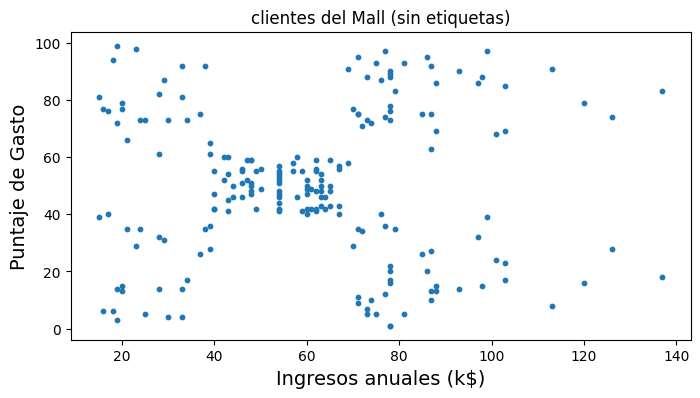

In [5]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.title("clientes del Mall (sin etiquetas)")
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.

In [6]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [7]:
# Centroides encontrados por K-Means
print("Centroides:")
print(kmeans.cluster_centers_)

Centroides:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [8]:
# Predicción de nuevos puntos
X_new = np.array([[50, 50], [100, 80], [20, 20], [80, 10]])
print("Cluster asignado a nuevos puntos:")
print(kmeans.predict(X_new))

Cluster asignado a nuevos puntos:
[0 1 4 3]


In [9]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=4)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("Annual Income (k$)", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("Spending Score", fontsize=14, rotation=90)
    else:
        plt.tick_params(labelleft=False)

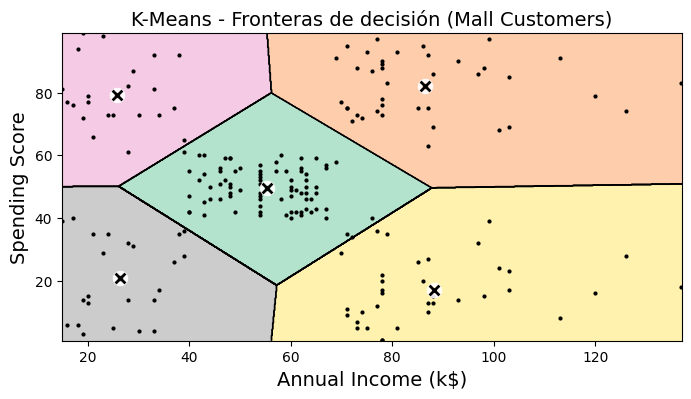

In [10]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.title("K-Means - Fronteras de decisión (Mall Customers)", fontsize=14)
plt.show()

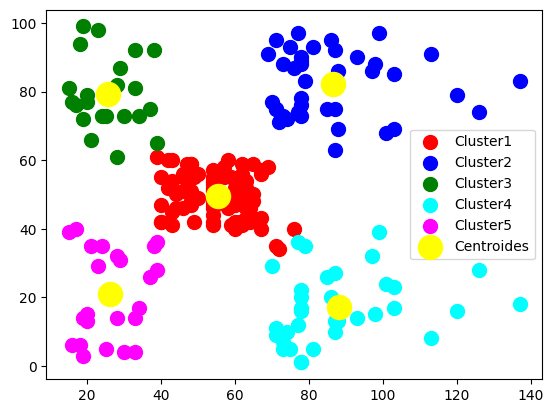

In [12]:
colors=['red','blue','green','cyan','magenta']

for i in range(5):
    plt.scatter(X[y_pred==i,0],X[y_pred==i,1],s=100,c=colors[i],label='Cluster'+str(i+1))
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centroides')
plt.legend()
plt.show()

    